# Tarea 01: Aproximación de una función desconocida

Generamos datos con una función que **nosotros definimos y ustedes no conocen**. Su
trabajo es reconstruirla a partir de los datos.

No es un acertijo: es lo que hace el machine learning todos los días. El capítulo 02
plantea el aprendizaje como **aproximación de funciones**, y aquí van a hacer
exactamente eso, con la ventaja rara de que existe una respuesta correcta y un límite
teórico al que se puede llegar.

## Lo que hay

- `train.csv`: 800 observaciones con 12 variables (`x1` a `x12`) y la respuesta `y`.
- `test.csv`: 400 observaciones con las mismas 12 variables, **sin** `y`.

Entregan sus 400 predicciones y un bot las califica automáticamente.

## Cómo se califica

| Su MSE en el conjunto de prueba | Calificación |
|---|---|
| Igual o peor que una regresión lineal con las 12 variables crudas | **5.0** |
| Igual al modelo bien especificado (el error irreducible) | **10.0** |
| En medio | proporcional a la mejora |

**El 5 está garantizado si entregan algo que corre.** El código del baseline se lo damos
hecho más abajo; de ahí para arriba es mérito suyo.

Tienen **3 intentos** de calificación. Un comentario `/validar` revisa el formato y les
dice cuál es su MSE objetivo **sin gastar intento**, así que úsenlo antes del primero.

## Qué se evalúa además del MSE

El MSE es la mitad. La otra mitad es la **Parte 5: la bitácora**, donde documentan cada
hipótesis que probaron — incluidas las que fallaron. Un notebook con buen MSE y bitácora
vacía vale poco: significa que no entendieron por qué funcionó.

---

## Las reglas sobre la IA

**Sí pueden usar IA. De hecho quiero que la usen.** Pero de una forma específica.

La IA no puede ver sus datos. Puede explicarles teoría, listarles técnicas o decirles qué
función de `matplotlib` usar. Lo que **no** puede hacer es mirar una gráfica de residuales
y decirles qué término falta, porque eso solo lo revela correr el código con *sus* datos, y
cada quien tiene datos distintos.

Así que la IA es su tutor, no su chofer. Para que sea tutor, péguenle esto al inicio de
cada conversación:

> Eres mi tutor de regresión, no mi resolvedor. Reglas: (1) no escribes código que yo
> pueda copiar; si te pido código, me devuelves el nombre de la función y su docstring.
> (2) No me das la respuesta: me preguntas qué espero ver y por qué. (3) Cuando me
> equivoque, no me corriges: me sugieres qué gráfica revelaría mi error. (4) Máximo
> tres oraciones por respuesta.

Y una regla para ustedes: **si la IA les da código y no pueden explicar qué hace línea
por línea, bórrenlo y escríbanlo ustedes.** Se nota en la bitácora, y se nota más en el
examen.

## Solución local · clave 208999

**Modelo de entrega:** mínimos cuadrados ordinarios (`LinearRegression`) sobre siete variables
explicativas. Las transformaciones son funciones fijas de las entradas; los siete
coeficientes y el intercepto se estiman mediante regresión lineal.

**Comparación requerida:** `PolynomialFeatures(3) → StandardScaler → LassoCV`,
con penalización elegida en desarrollo y número de coeficientes no nulos reportado.

**Protocolo:** 600 filas para exploración y selección, validación cruzada de 5 partes
repetida 4 veces dentro de esas 600, y 200 filas reservadas para una auditoría final.
El archivo `test.csv` se utiliza únicamente para predecir al final. Ninguna celda
contacta el bot de calificación ni consume intentos.

**Autoría:** análisis y código preparados con asistencia de IA. La bitácora documenta
ejecuciones reales de esa asistencia, no experiencias personales atribuidas al alumno.
Debe revisarse y entenderse antes de entregar. Las instrucciones originales del curso
están arriba y en `tarea_01_README.md`.

La CV de desarrollo es adaptativa: los términos se eligieron usando esas filas.
No se presenta como una estimación independiente de todo el proceso de búsqueda.

In [1]:
import hashlib
import json
import platform
import warnings
from itertools import combinations
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import display
import sklearn
from sklearn.base import clone
from sklearn.exceptions import ConvergenceWarning
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score
from sklearn.model_selection import KFold, RepeatedKFold, cross_val_predict, cross_val_score, train_test_split
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import PolynomialFeatures, StandardScaler
from threadpoolctl import threadpool_limits

threadpool_limits(limits=1)
sns.set_theme(style="whitegrid", palette="colorblind")
plt.rcParams["figure.dpi"] = 100
SEMILLA = 42
CLAVE_UNICA = "208999"

# Una falta de convergencia debe detener la ejecución, no esconderse.
warnings.filterwarnings("error", category=ConvergenceWarning)

## Parte 0. Datos y separación de la auditoría

La partición se fija antes de mirar gráficas o comparar candidatos. Todas las gráficas
de exploración usan solamente las 600 filas de desarrollo. La auditoría se consulta
una vez, después de congelar la especificación; no se hacen ajustes a partir de su resultado.

La auditoría ya se consultó en la primera versión de esta solución. Ahora se reutiliza
para informar la comparación de Lasso; no se utiliza para retocar la fórmula de entrega.
Volver a ejecutar este notebook no crea una auditoría nueva.

In [2]:
_clave = "".join(c for c in CLAVE_UNICA if c.isdigit()).zfill(9)
CARPETA = "v" + hashlib.sha256(_clave.encode()).hexdigest()[:8]
RAIZ = next(p for p in [Path.cwd(), *Path.cwd().parents]
            if (p / "tareas/tarea_01_datos").is_dir())
MIS_DATOS = RAIZ / "tareas/tarea_01_datos" / CARPETA
RESULTADOS = RAIZ / "tareas/resultados_208999"
RESULTADOS.mkdir(parents=True, exist_ok=True)
VARIABLES = [f"x{i}" for i in range(1, 13)]

train = pd.read_csv(MIS_DATOS / "train.csv")
assert CARPETA == "v2e419aae"
assert train.shape == (800, 13)
assert list(train.columns) == VARIABLES + ["y"]
assert np.isfinite(train.to_numpy()).all()
desarrollo, auditoria = train_test_split(train, test_size=0.25, random_state=SEMILLA)
X_train, y_train = desarrollo[VARIABLES], desarrollo["y"]
X_val, y_val = auditoria[VARIABLES], auditoria["y"]
assert set(desarrollo.index).isdisjoint(auditoria.index)
assert set(desarrollo.index) | set(auditoria.index) == set(train.index)
PLIEGUES = list(RepeatedKFold(n_splits=5, n_repeats=4, random_state=137).split(X_train))
print(f"Variante: {CARPETA} | Desarrollo: {len(desarrollo)} | Auditoría: {len(auditoria)}")
display(desarrollo.describe().T)
print(f"Faltantes en train: {train.isna().sum().sum()}")

Variante: v2e419aae | Desarrollo: 600 | Auditoría: 200


,count,mean,std,min,25%,50%,75%,max
x1,600.0,0.015473,0.283898,-0.499434,-0.219149,0.027269,0.262582,0.499635
x2,600.0,0.019875,1.147473,-1.989782,-0.958354,-0.018201,1.061409,1.999772
x3,600.0,1.753892,2.399074,0.024796,0.444150,0.984011,2.053349,21.424731
x4,600.0,1.988060,1.173369,0.002938,1.005792,1.952618,3.003392,3.990735
x5,600.0,0.003712,1.077328,-3.151756,-0.781378,-0.068200,0.788172,3.149425
x6,600.0,1.807893,2.754197,0.049519,0.512252,0.950531,1.955498,32.233148
x7,600.0,0.103779,1.131785,-1.993409,-0.886668,0.140961,1.108420,1.998438
x8,600.0,0.009277,0.279798,-0.498945,-0.205820,-0.002564,0.253341,0.498692
x9,600.0,50.416705,28.599537,0.054050,26.486576,51.494259,75.204348,99.933983
x10,600.0,0.012066,1.768490,-2.997272,-1.473694,-0.019605,1.598321,2.995449


Faltantes en train: 0


In [3]:
def evaluar_cv(matriz):
    """MSE OLS en desarrollo con los mismos 20 pliegues para cada candidato."""
    errores = -cross_val_score(
        LinearRegression(), matriz, y_train, cv=PLIEGUES,
        scoring="neg_mean_squared_error", n_jobs=1, error_score="raise",
    )
    return {"MSE_CV": float(errores.mean()), "DE_pliegues": float(errores.std(ddof=1)),
            "columnas": matriz.shape[1]}


def guardar_figura(nombre):
    plt.tight_layout()
    plt.savefig(RESULTADOS / nombre, dpi=130, bbox_inches="tight")
    plt.show()
    plt.close()


cv_baseline = evaluar_cv(X_train)
print(f"Baseline de 12 variables crudas: MSE CV = {cv_baseline['MSE_CV']:.4f}")

Baseline de 12 variables crudas: MSE CV = 104.6655


## Parte 1. Exploración

Las variables tienen escalas y distribuciones distintas. Una correlación marginal
pequeña no descarta un efecto no lineal ni una interacción.

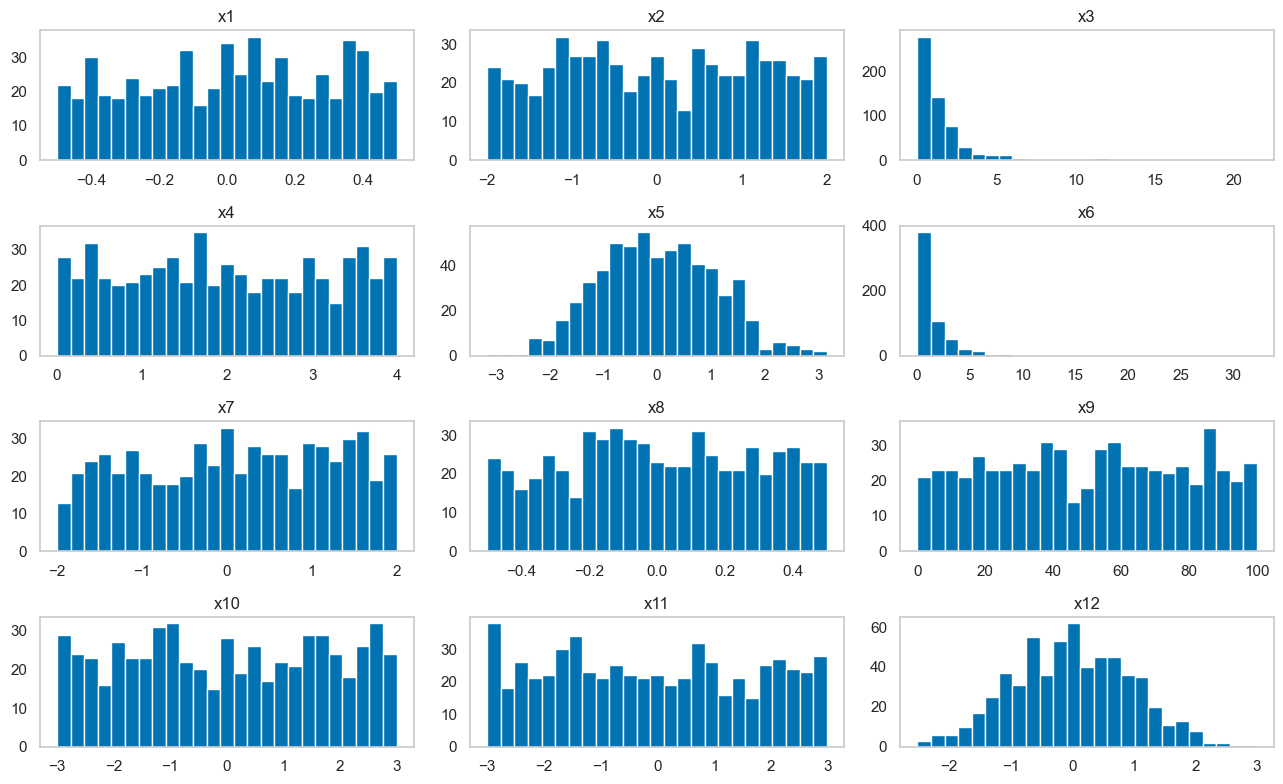

In [4]:
desarrollo[VARIABLES].hist(bins=25, figsize=(13, 8), grid=False)
guardar_figura("01_distribuciones.png")

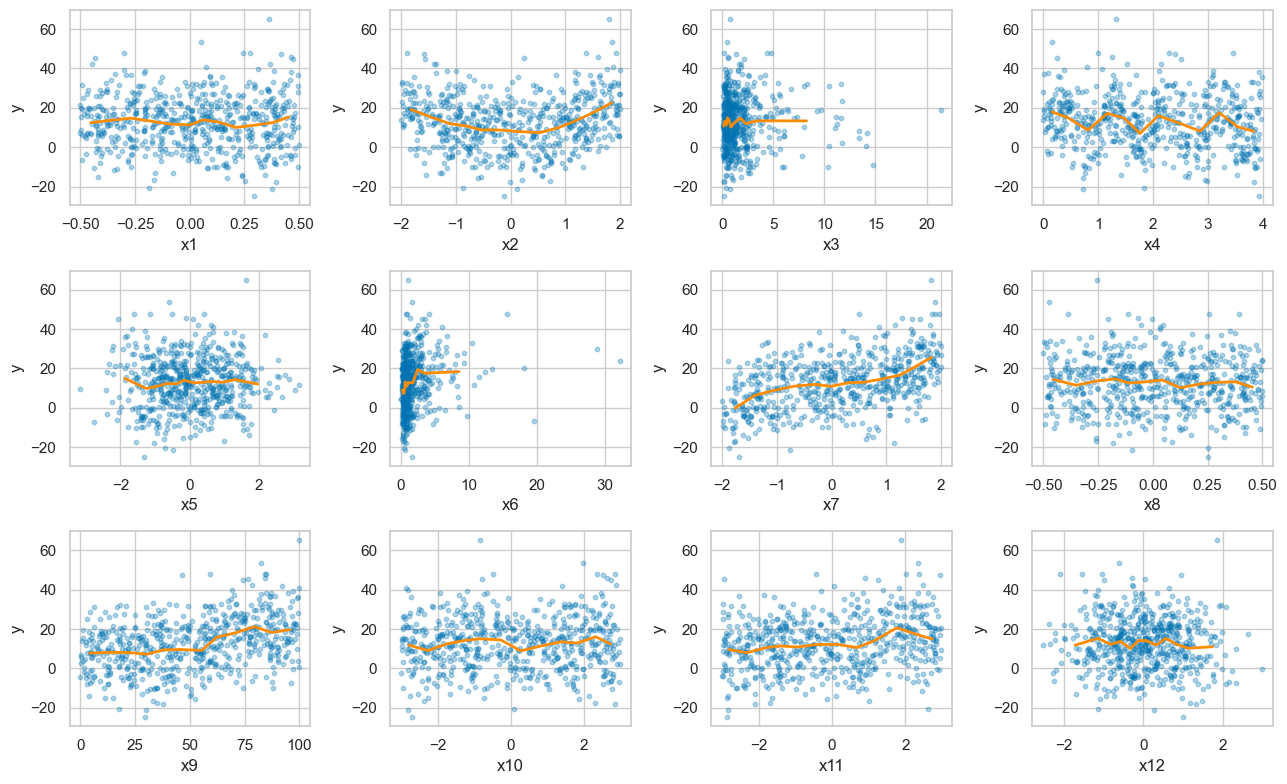

In [5]:
def paneles_respuesta(datos, respuesta, titulo, nombre):
    fig, axes = plt.subplots(3, 4, figsize=(13, 8))
    for variable, ax in zip(VARIABLES, axes.flat):
        ax.scatter(datos[variable], respuesta, s=10, alpha=0.3)
        grupos = pd.qcut(datos[variable], q=12, duplicates="drop")
        resumen = pd.DataFrame({"x": datos[variable], "y": np.asarray(respuesta)}).groupby(
            grupos, observed=True
        ).mean()
        ax.plot(resumen["x"], resumen["y"], color="darkorange", linewidth=2)
        if "Residual" in titulo:
            ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
        ax.set(xlabel=variable, ylabel=titulo)
    guardar_figura(nombre)


paneles_respuesta(X_train, y_train, "y", "02_respuesta.png")

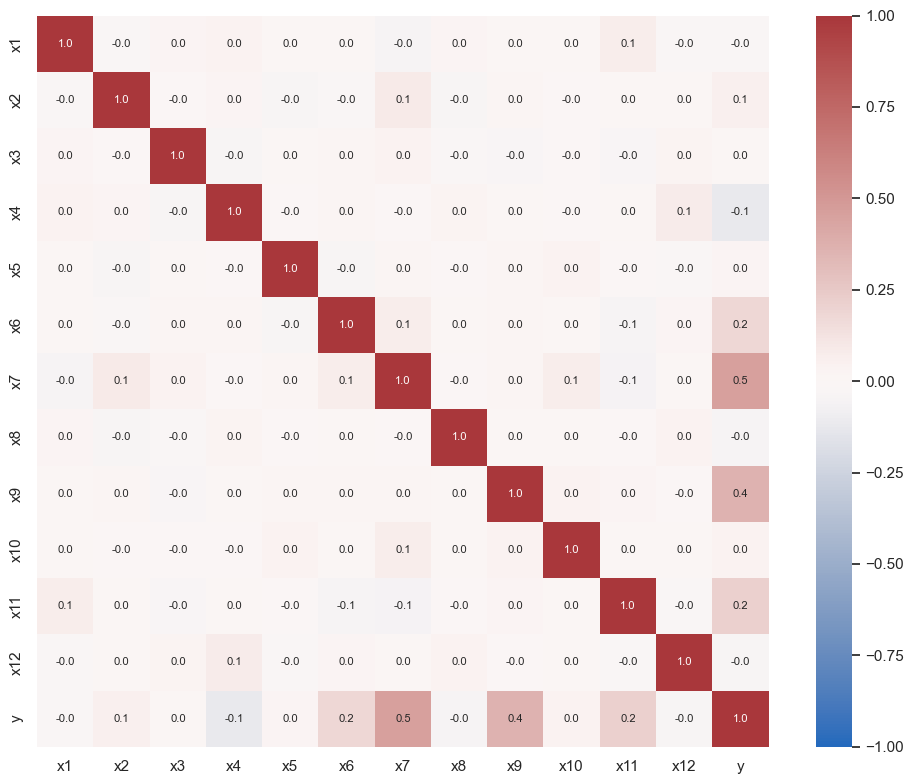

In [6]:
plt.figure(figsize=(10, 8))
sns.heatmap(desarrollo.corr(), cmap="vlag", center=0, vmin=-1, vmax=1,
            annot=True, fmt=".1f", annot_kws={"size": 8}, square=True)
guardar_figura("03_correlacion.png")

### 1.1 Lectura de las gráficas

Esta tabla es una síntesis retrospectiva asistida por IA, no un registro personal
escrito por el alumno antes de explorar.

| Variable | Lectura inicial | Evidencia | Certeza inicial |
|---|---|---|---|
| x1 | Marginalmente débil; no descarta interacción | Dispersión/correlación | Baja |
| x2 | Curvatura aproximadamente cuadrática | Residuales del baseline | Alta |
| x3 | Asimetría positiva; efecto marginal poco claro | Histograma/dispersión | Baja |
| x4 | Oscilación que una recta no representa | Dispersión/residuales | Media |
| x5 | Efecto marginal poco claro | Dispersión/correlación | Baja |
| x6 | Cola derecha y relación posiblemente logarítmica | Histograma/residuales | Media |
| x7 | Tendencia creciente con curvatura | Dispersión/residuales | Alta |
| x8 | Efecto marginal poco claro | Dispersión/correlación | Baja |
| x9 | Cambio de nivel posible | Dispersión y residuales tras otros términos | Media |
| x10 | Efecto marginal poco claro | Dispersión/correlación | Baja |
| x11 | Tendencia lineal e interacción posible | Correlación; análisis de pares posterior | Media |
| x12 | Efecto marginal poco claro | Dispersión/correlación | Baja |

## Parte 2. Escalera de residuales

Se comparan términos individuales conservando inicialmente las 12 variables crudas.
La búsqueda exploratoria probó potencias, valores absolutos, logaritmos, exponenciales,
senos/cosenos, escalones y productos de pares sobre desarrollo. La siguiente escalera
reproduce las hipótesis principales con una especificación legible.

Los residuales fuera de muestra se obtienen con el primer ciclo de 5 pliegues;
cada punto se predice con un ajuste que excluyó ese punto. Como la selección de términos
sí utilizó desarrollo, estas gráficas son diagnósticos y no sustituyen la auditoría.

Se conservan los 12 paneles después de cada paso, con una referencia horizontal en cero.
Las figuras y las tablas permiten revisar qué estructura desaparece al agregar cada término.

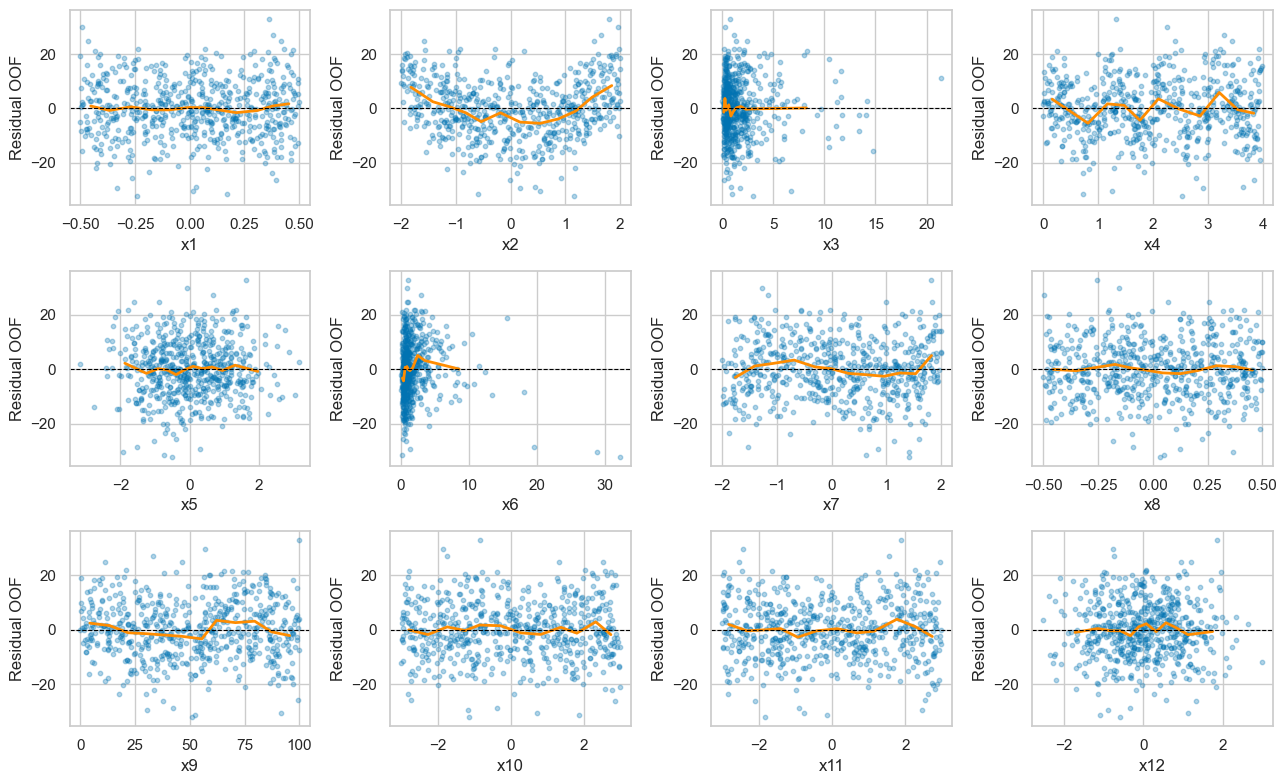

In [7]:
TERMINOS = {
    "x2_cuadrado": lambda d: d["x2"] ** 2,
    "seno_x4": lambda d: np.sin(2 * np.pi * d["x4"]),
    "log_x6": lambda d: np.log(d["x6"]),
    "x7_cubo": lambda d: d["x7"] ** 3,
    "escalon_x9": lambda d: (d["x9"] > 60).astype(float),
    "interaccion_x1_x11": lambda d: d["x1"] * d["x11"],
}


def construir(datos, nombres=(), crudas=True):
    """Mismas transformaciones en desarrollo, auditoría y test; sin ajuste oculto."""
    salida = datos[VARIABLES].copy() if crudas else datos[["x11"]].copy()
    if "log_x6" in nombres and (datos["x6"] <= 0).any():
        raise ValueError("log(x6) requiere valores positivos.")
    for nombre in nombres:
        salida[nombre] = TERMINOS[nombre](datos)
    if not np.isfinite(salida.to_numpy()).all():
        raise ValueError("La matriz contiene valores no finitos.")
    return salida


def residuales_cv(matriz):
    pred = cross_val_predict(LinearRegression(), matriz, y_train, cv=PLIEGUES[:5])
    return y_train.to_numpy() - pred


paneles_respuesta(X_train, residuales_cv(X_train), "Residual OOF", "04_residuales_baseline.png")

Paso 1: + x2_cuadrado; MSE CV 83.3429


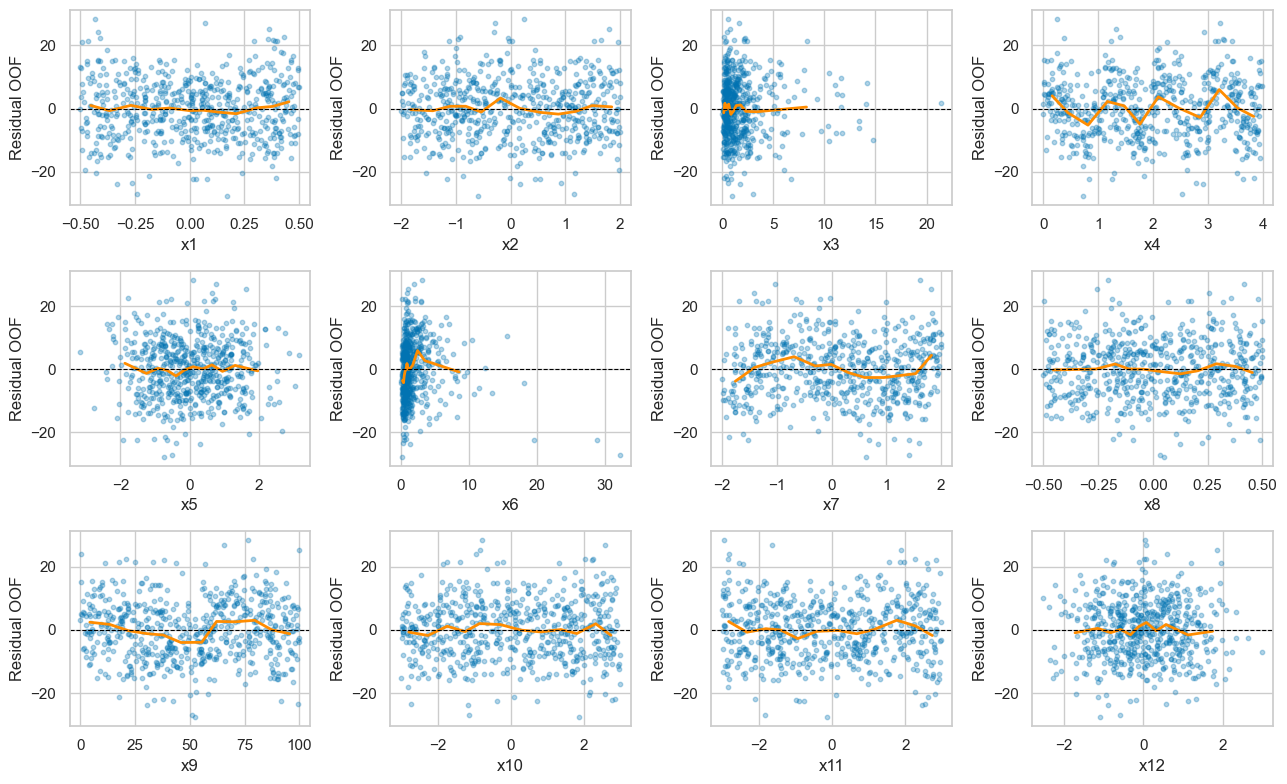

Paso 2: + seno_x4; MSE CV 65.9044


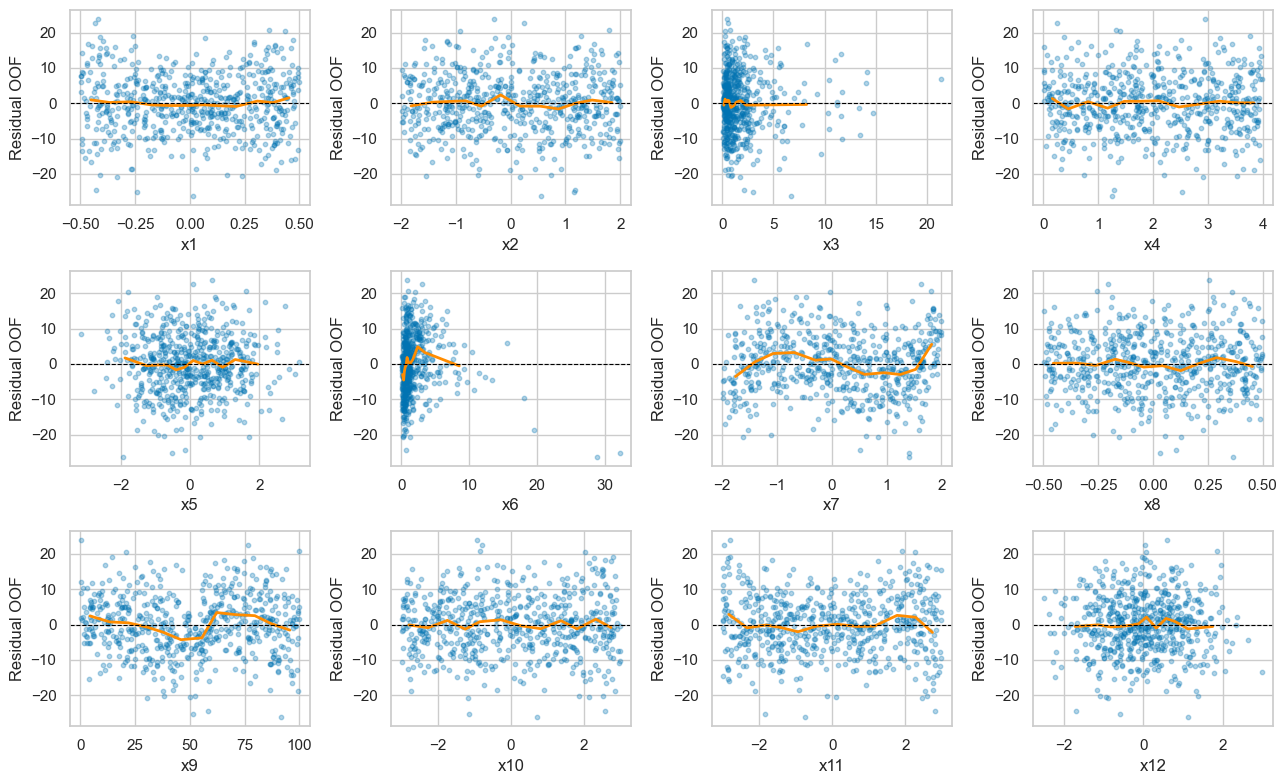

Paso 3: + log_x6; MSE CV 58.8534


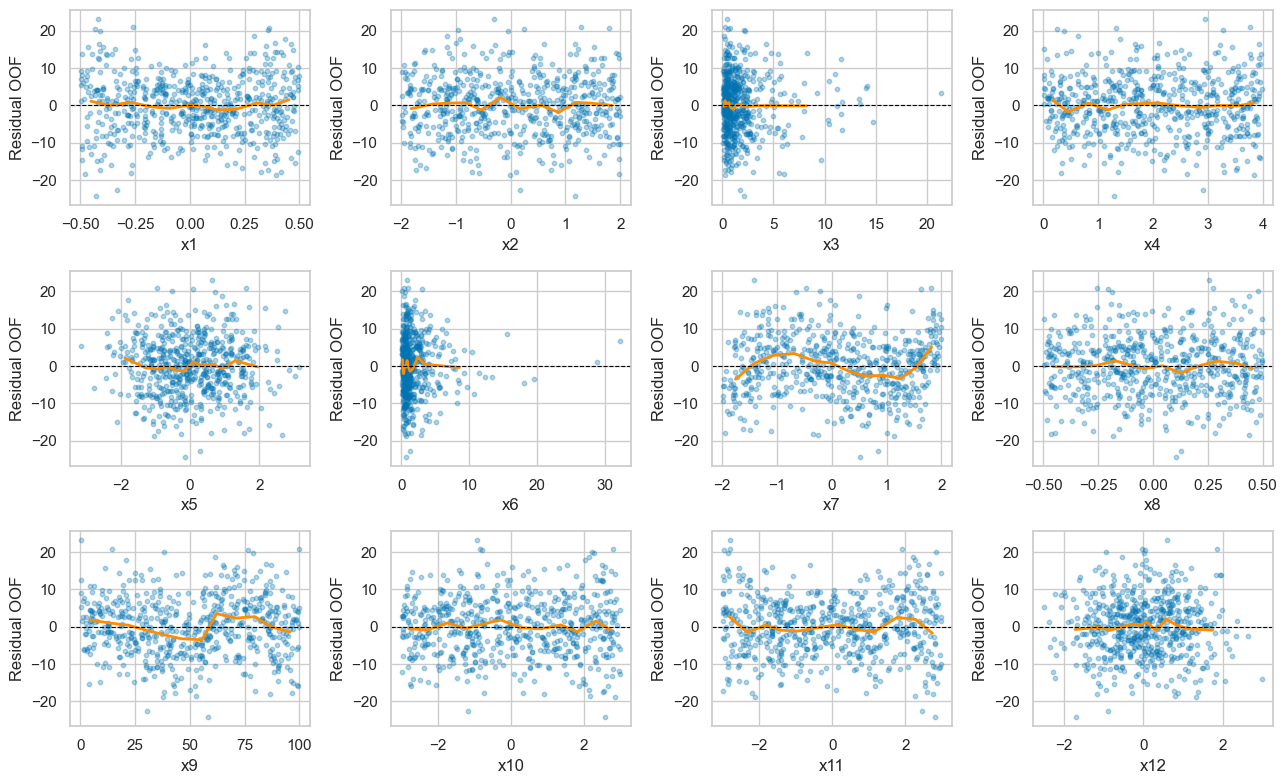

Paso 4: + x7_cubo; MSE CV 51.0205


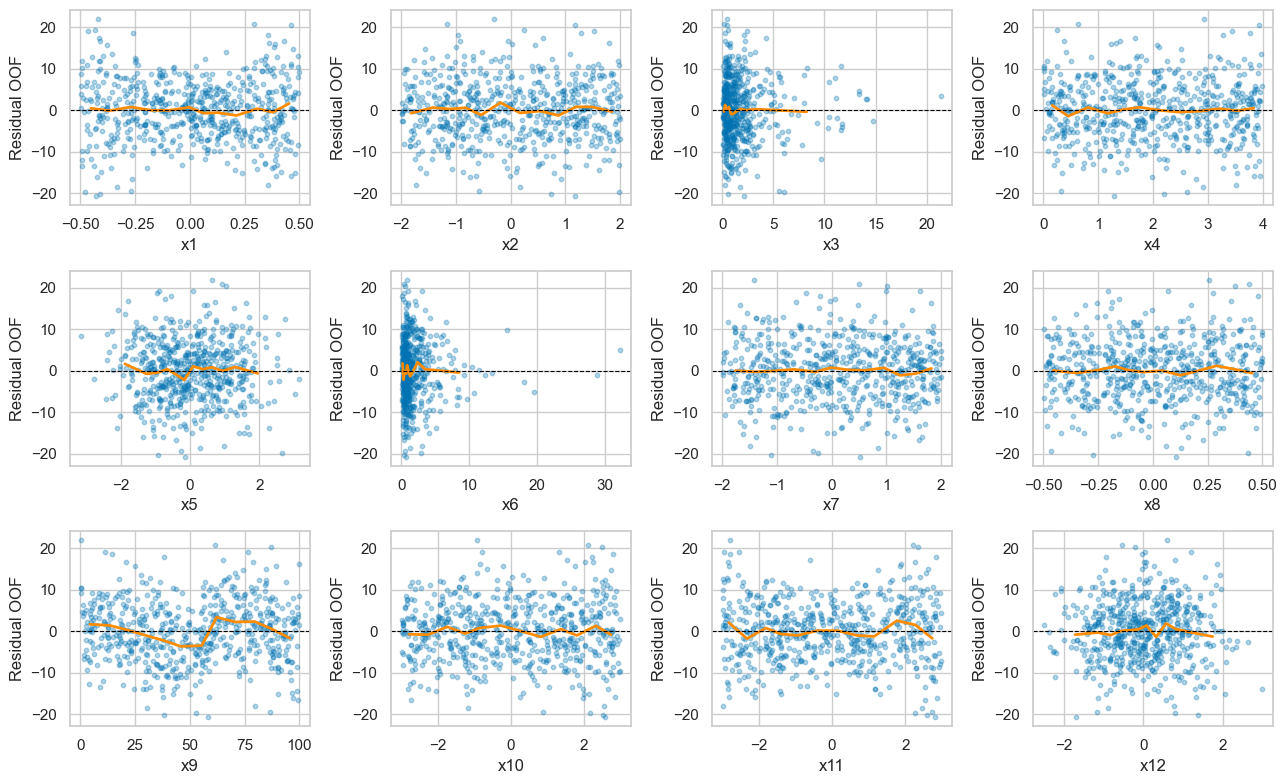

Paso 5: + escalon_x9; MSE CV 47.0168


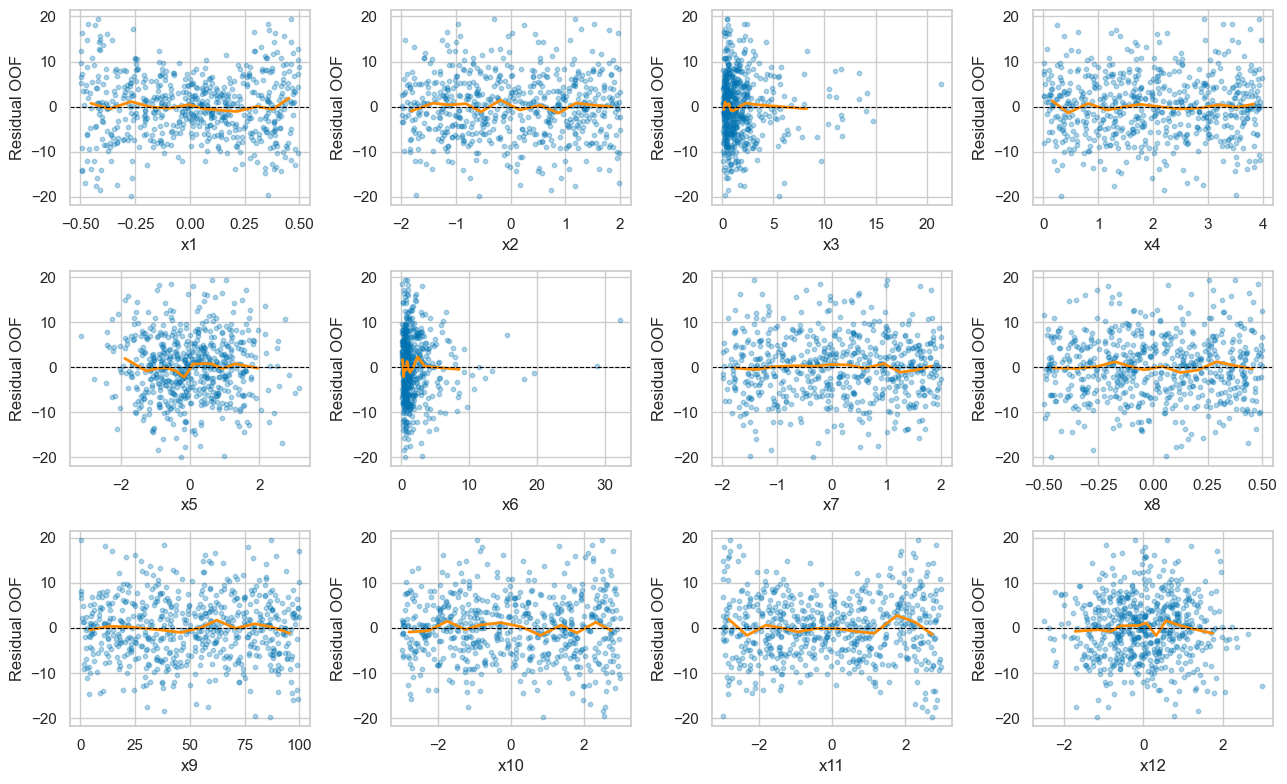

,modelo,columnas,MSE_CV,DE_pliegues
0,Baseline,12,104.665513,15.090984
1,+ x2_cuadrado,13,83.342852,11.709170
2,+ seno_x4,14,65.904422,9.553964
3,+ log_x6,15,58.853375,7.669396
4,+ x7_cubo,16,51.020517,6.055486
5,+ escalon_x9,17,47.016759,5.748900


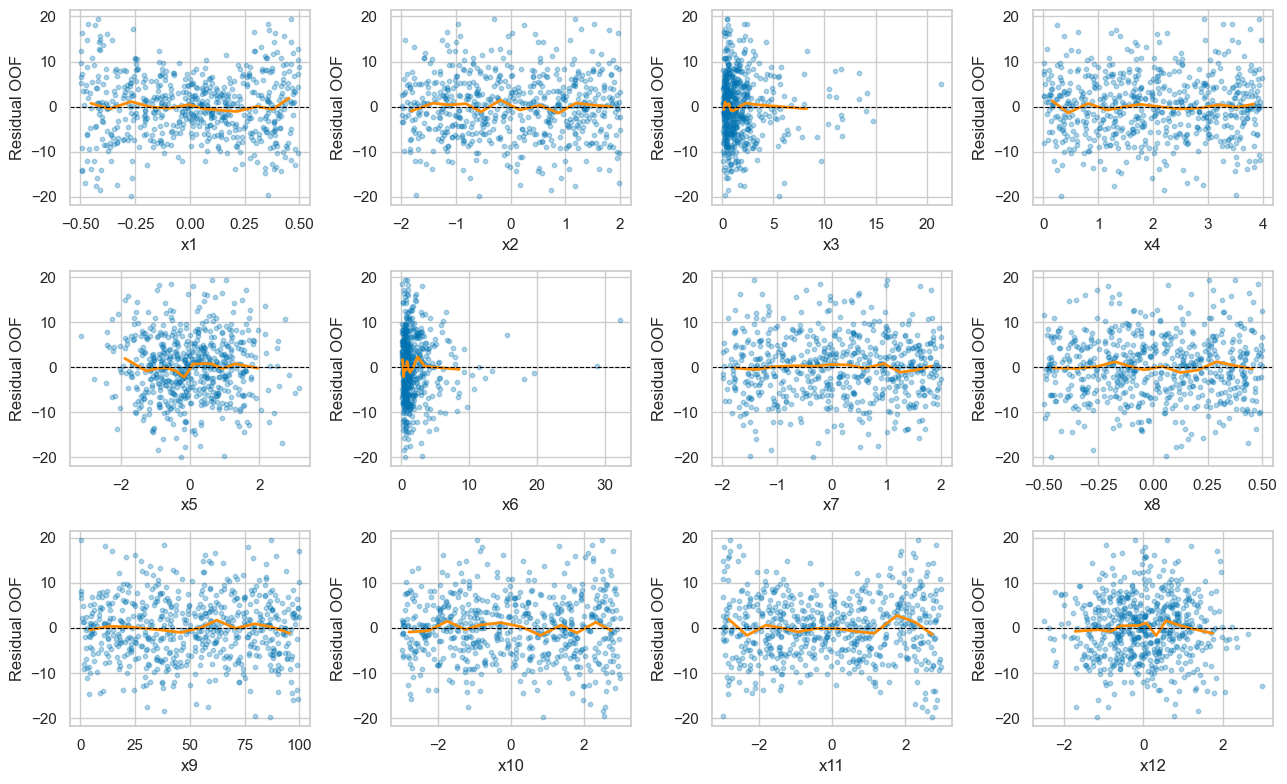

In [8]:
etapas = [{"modelo": "Baseline", "terminos": [], "crudas": True, **cv_baseline}]
seleccion = []
for paso, nombre in enumerate(list(TERMINOS)[:5], start=1):
    seleccion = seleccion + [nombre]
    matriz_paso = construir(X_train, seleccion)
    etapas.append({"modelo": f"+ {nombre}", "terminos": seleccion.copy(), "crudas": True,
                   **evaluar_cv(matriz_paso)})
    print(f"Paso {paso}: + {nombre}; MSE CV {etapas[-1]['MSE_CV']:.4f}")
    paneles_respuesta(X_train, residuales_cv(matriz_paso), "Residual OOF",
                     f"residuales_paso_{paso:02d}.png")
display(pd.DataFrame(etapas)[["modelo", "columnas", "MSE_CV", "DE_pliegues"]])
paneles_respuesta(X_train, residuales_cv(matriz_paso),
                 "Residual OOF", "05_residuales_aditivo.png")

## Parte 3. Interacciones

El producto `x1*x11` permite que la pendiente respecto a `x11` cambie con `x1`.
Una gráfica marginal puede ocultar ese efecto: al promediar valores positivos y
negativos de `x1`, las pendientes se cancelan parcialmente.

,par,MSE_CV,DE_pliegues,columnas
9,x1*x11,20.067056,2.600929,18
39,x5*x7,46.700544,5.865735,18
4,x1*x6,46.823801,5.744941,18
53,x7*x10,46.830932,5.860641,18
50,x6*x12,46.867836,5.724708,18
42,x5*x10,46.894775,5.610315,18
1,x1*x3,46.947235,5.819602,18
8,x1*x10,46.948492,5.680588,18
45,x6*x7,46.956468,5.726507,18
58,x8*x11,47.010156,5.632206,18


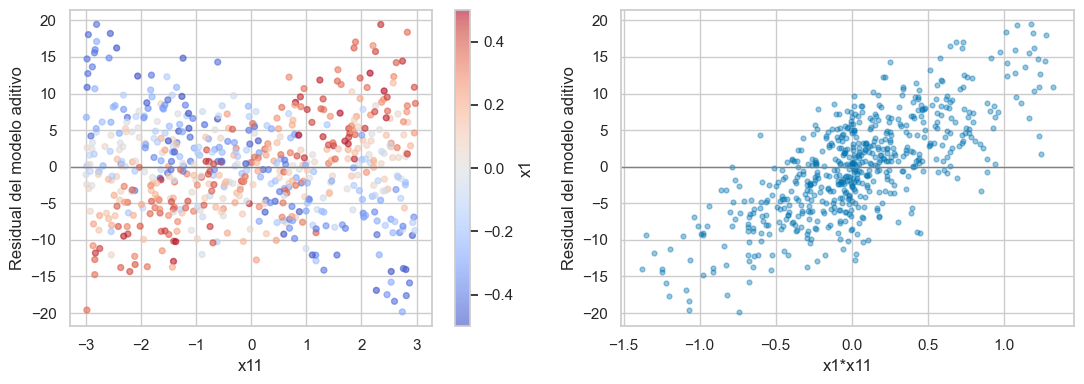

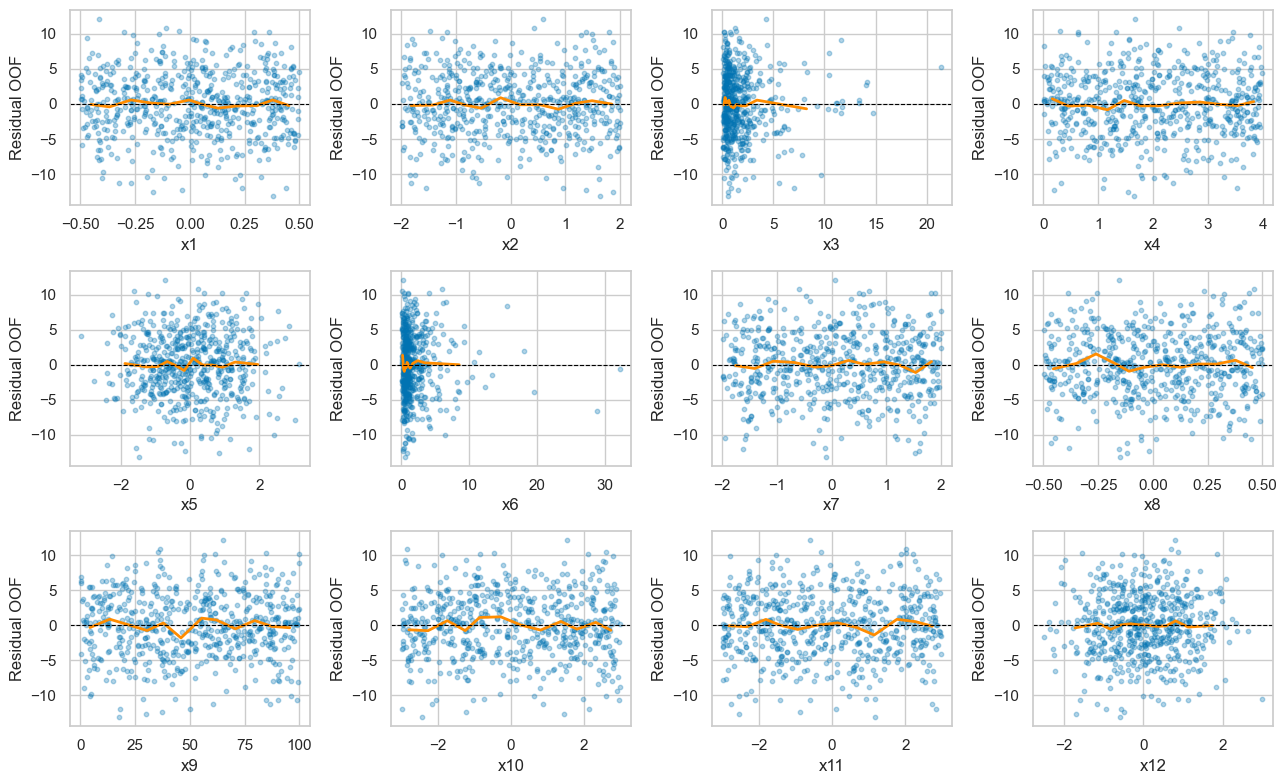

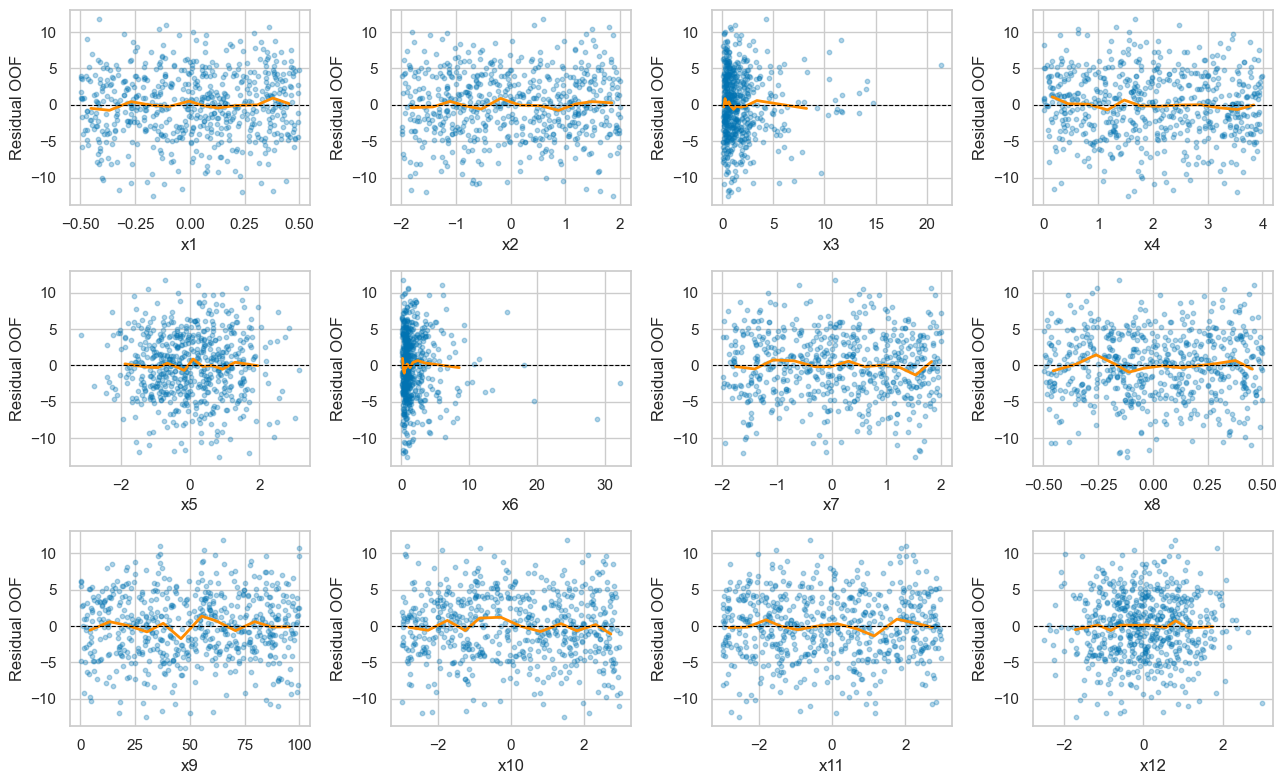

,modelo,columnas,MSE_CV,DE_pliegues
0,Baseline,12,104.665513,15.090984
1,+ x2_cuadrado,13,83.342852,11.709170
2,+ seno_x4,14,65.904422,9.553964
3,+ log_x6,15,58.853375,7.669396
4,+ x7_cubo,16,51.020517,6.055486
5,+ escalon_x9,17,47.016759,5.748900
6,+ interacción x1*x11,18,20.067056,2.600929
7,Compacto: siete columnas,7,19.594995,2.583786


In [9]:
# Comparar los 66 productos evita afirmar una interacción sólo por un scatter.
matriz_aditiva = construir(X_train, seleccion)
ranking_pares = []
for a, b in combinations(VARIABLES, 2):
    candidato = matriz_aditiva.copy()
    candidato[f"{a}*{b}"] = X_train[a] * X_train[b]
    ranking_pares.append({"par": f"{a}*{b}", **evaluar_cv(candidato)})
tabla_pares = pd.DataFrame(ranking_pares).sort_values("MSE_CV")
tabla_pares.to_csv(RESULTADOS / "interacciones_cv.csv", index=False)
display(tabla_pares.head(10))

residuales_aditivos = residuales_cv(matriz_aditiva)
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
nube = axes[0].scatter(X_train["x11"], residuales_aditivos, c=X_train["x1"],
                       cmap="coolwarm", alpha=0.6, s=18)
axes[0].axhline(0, color="gray", linewidth=1)
axes[0].set(xlabel="x11", ylabel="Residual del modelo aditivo")
fig.colorbar(nube, ax=axes[0], label="x1")
producto = X_train["x1"] * X_train["x11"]
axes[1].scatter(producto, residuales_aditivos, s=12, alpha=0.4)
axes[1].axhline(0, color="gray", linewidth=1)
axes[1].set(xlabel="x1*x11", ylabel="Residual del modelo aditivo")
guardar_figura("06_interaccion.png")

seleccion = list(TERMINOS)
etapas.append({"modelo": "+ interacción x1*x11", "terminos": seleccion.copy(), "crudas": True,
               **evaluar_cv(construir(X_train, seleccion))})
paneles_respuesta(X_train, residuales_cv(construir(X_train, seleccion)),
                 "Residual OOF", "residuales_paso_06.png")
etapas.append({"modelo": "Compacto: siete columnas", "terminos": seleccion.copy(), "crudas": False,
               **evaluar_cv(construir(X_train, seleccion, crudas=False))})
paneles_respuesta(X_train, residuales_cv(construir(X_train, seleccion, crudas=False)),
                 "Residual OOF", "residuales_compacto.png")
display(pd.DataFrame(etapas)[["modelo", "columnas", "MSE_CV", "DE_pliegues"]])

### Comparación de alternativas y simplificación

Se comparó `log`, `log1p` y raíz cuadrada para `x6`, con y sin las variables crudas;
para el escalón se probaron umbrales 58, 59, 59.5, 59.75, 60, 60.25, 60.5, 61 y 62.
Se probaron también columnas crudas adicionales en el modelo compacto.
`log(x6)` y el umbral 60 ofrecieron la mejor combinación compacta de esa rejilla.

Una búsqueda más extensa llegó a 28 columnas y MSE CV 18.72, frente a 19.59 con siete.
Ese valor se obtuvo tras seleccionar repetidamente usando desarrollo, por lo que puede
ser optimista. Se prefirió la especificación de siete columnas por su sencillez y
porque las reducciones adicionales eran pequeñas frente a la variación entre pliegues.
No se afirma que sea el mínimo absoluto entre todas las regresiones posibles.

El registro principal conserva las hipótesis interpretables; las rejillas de transformaciones,
umbrales y pares quedan completas en los CSV de resultados, incluidas sus alternativas descartadas.

,familia,crudas,umbral,MSE_CV,DE_pliegues,columnas
13,log,False,60.00,19.594995,2.583786,7
14,log,False,60.25,19.691538,2.664513,7
15,log,False,60.50,19.695557,2.668552,7
12,log,False,59.75,19.700873,2.511568,7
11,log,False,59.50,19.836678,2.479080,7
16,log,False,61.00,19.970066,2.538864,7
4,log,True,60.00,20.067056,2.600929,18
6,log,True,60.50,20.148085,2.682227,18
3,log,True,59.75,20.148448,2.546675,18
5,log,True,60.25,20.153364,2.669543,18


Reemplazar x2² por exp(0.5*x2): MSE CV 20.7490


,extras,MSE_CV,DE_pliegues,columnas
0,ninguna,19.594995,2.583786,7
1,x7,19.610108,2.521248,8
2,x6,19.574229,2.534334,8
3,"x7, x6",19.599538,2.483724,9
4,x9,19.595267,2.613292,8
5,"x7, x6, x9",19.597173,2.514626,10


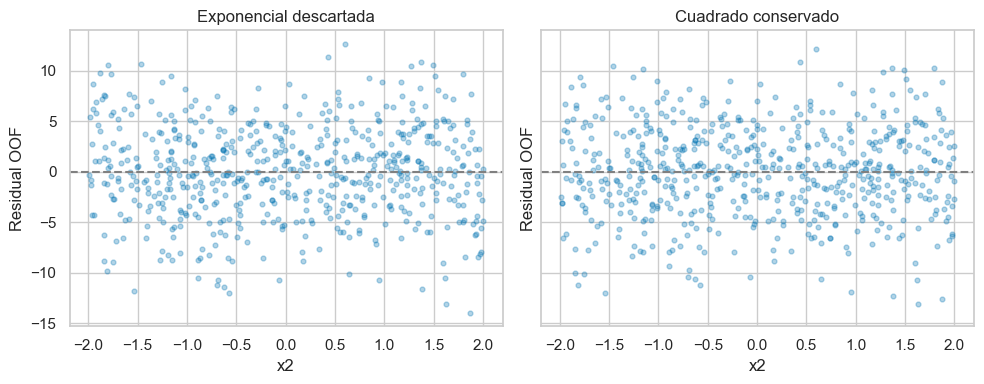

In [10]:
alternativas = []
for familia, funcion in [("log", np.log), ("log1p", np.log1p), ("sqrt", np.sqrt)]:
    for crudas in [True, False]:
        for umbral in [58, 59, 59.5, 59.75, 60, 60.25, 60.5, 61, 62]:
            matriz = construir(X_train, seleccion, crudas=crudas)
            matriz["log_x6"] = funcion(X_train["x6"])
            matriz["escalon_x9"] = (X_train["x9"] > umbral).astype(float)
            alternativas.append({"familia": familia, "crudas": crudas, "umbral": umbral,
                                  **evaluar_cv(matriz)})
tabla_alternativas = pd.DataFrame(alternativas).sort_values("MSE_CV")
tabla_alternativas.to_csv(RESULTADOS / "alternativas_cv.csv", index=False)
display(tabla_alternativas.head(10))

matriz_exponencial = construir(X_train, seleccion).drop(columns="x2_cuadrado")
matriz_exponencial["exp_x2"] = np.exp(0.5 * X_train["x2"])
cv_exponencial = evaluar_cv(matriz_exponencial)
print(f"Reemplazar x2² por exp(0.5*x2): MSE CV {cv_exponencial['MSE_CV']:.4f}")

# Sensibilidad: agregar variables crudas a las siete columnas ya elegidas.
sensibilidad = []
for extras in [[], ["x7"], ["x6"], ["x7", "x6"], ["x9"], ["x7", "x6", "x9"]]:
    matriz = construir(X_train, seleccion, crudas=False)
    for variable in extras:
        matriz[variable] = X_train[variable]
    sensibilidad.append({"extras": ", ".join(extras) or "ninguna", **evaluar_cv(matriz)})
tabla_sensibilidad = pd.DataFrame(sensibilidad)
tabla_sensibilidad.to_csv(RESULTADOS / "sensibilidad_cv.csv", index=False)
display(tabla_sensibilidad)

# Diagnóstico visual del callejón sin salida de la exponencial.
res_exponencial = residuales_cv(matriz_exponencial)
res_cuadrado = residuales_cv(construir(X_train, seleccion))
fig, axes = plt.subplots(1, 2, figsize=(10, 4), sharey=True)
for ax, residuos, titulo in zip(axes, [res_exponencial, res_cuadrado],
                               ["Exponencial descartada", "Cuadrado conservado"]):
    ax.scatter(X_train["x2"], residuos, alpha=0.3, s=12)
    ax.axhline(0, color="gray", linestyle="--")
    ax.set(xlabel="x2", ylabel="Residual OOF", title=titulo)
guardar_figura("hipotesis_exponencial.png")


## Parte 4. Fuerza bruta: polinomios y LassoCV

Se implementa el pipeline solicitado: `PolynomialFeatures(degree=3, include_bias=False)`
→ `StandardScaler` → `LassoCV`. Se generan **454 columnas** y la penalización L1
puede dejar coeficientes exactamente en cero. Se estandariza para penalizar variables
en una escala comparable; el intercepto no forma parte de las columnas penalizadas.

`LassoCV` compara 60 valores de `alpha` entre aproximadamente 0.032 y 31.6, usando
5 pliegues internos. Esta rejilla se fija en desarrollo, con semillas reproducibles.
Se verifican convergencia y selección fuera de los extremos de la rejilla.

Para comparar, el pipeline completo se vuelve a ajustar dentro de cada uno de los
20 pliegues externos de desarrollo. El escalador no ve las filas externas de validación
ni las 200 filas de auditoría. El CV interno de `LassoCV` opera sobre la matriz ya
escalada del entrenamiento externo: su error sirve para elegir `alpha`, no se reporta
como estimación independiente de generalización. Las métricas comparables son el CV
externo y la auditoría. Todas las familias siguen siendo regresiones lineales en sus coeficientes.

LassoCV: alpha = 0.525217; 34/454 columnas no nulas.
Iteraciones del ajuste: 53; dual gap: 0.0100565


,termino,coeficiente_estandarizado,activo
398,x7^3,5.256048,True
22,x1 x11,4.072622,True
80,x9^2,3.196767,True
24,x2^2,2.555750,True
10,x11,1.909316,True
175,x2^2 x9,1.698713,True
5,x6,1.434867,True
3,x4,-0.926713,True
336,x5^2 x7,0.503848,True
414,x7 x10 x11,0.437036,True


Lasso: 5/20 pliegues externos completados.


Lasso: 10/20 pliegues externos completados.


Lasso: 15/20 pliegues externos completados.


Lasso: 20/20 pliegues externos completados.


,modelo,MSE_CV,DE_pliegues,columnas
0,Lineal crudo,104.665513,15.090984,12
1,Lineal compacto,19.594995,2.583786,7
2,Polinomio grado 3 + LassoCV,57.349237,6.783959,454
3,Polinomio grado 2 + OLS,71.771784,14.688619,90
4,Polinomio grado 3 + OLS,25089.063913,41000.240938,454


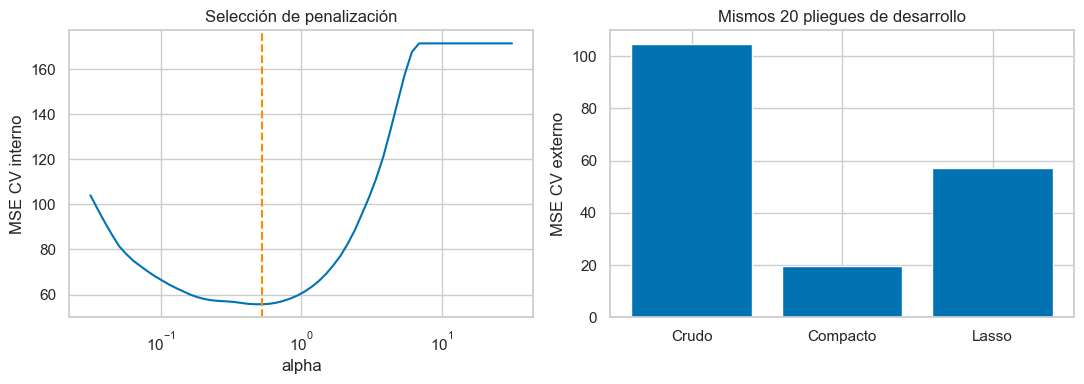

Menor MSE CV entre las dos estrategias: Compacto.


In [11]:
def crear_lasso():
    """Pipeline del enunciado; todos los ajustes se realizan sólo con filas de entrenamiento."""
    return make_pipeline(
        PolynomialFeatures(degree=3, include_bias=False),
        StandardScaler(),
        LassoCV(alphas=np.logspace(-1.5, 1.5, 60),
                cv=KFold(n_splits=5, shuffle=True, random_state=SEMILLA),
                max_iter=50000, tol=1e-4, n_jobs=1, selection="cyclic"),
    )


def revisar_lasso(pipeline, filas):
    ajuste = pipeline.named_steps["lassocv"]
    assert pipeline.named_steps["polynomialfeatures"].n_output_features_ == 454
    assert int(pipeline.named_steps["standardscaler"].n_samples_seen_) == filas
    assert ajuste.n_iter_ < ajuste.max_iter
    assert np.isfinite(ajuste.coef_).all()
    assert ajuste.alphas_.min() < ajuste.alpha_ < ajuste.alphas_.max()


modelo_lasso = crear_lasso().fit(X_train, y_train)
revisar_lasso(modelo_lasso, len(X_train))
ajuste_lasso = modelo_lasso.named_steps["lassocv"]
nombres_polinomio = modelo_lasso.named_steps["polynomialfeatures"].get_feature_names_out(VARIABLES)
coeficientes_lasso = pd.DataFrame({"termino": nombres_polinomio,
                                  "coeficiente_estandarizado": ajuste_lasso.coef_})
coeficientes_lasso["activo"] = coeficientes_lasso["coeficiente_estandarizado"] != 0
coeficientes_lasso.to_csv(RESULTADOS / "coeficientes_lasso.csv", index=False)
no_cero_lasso = int(coeficientes_lasso["activo"].sum())
print(f"LassoCV: alpha = {ajuste_lasso.alpha_:.6f}; {no_cero_lasso}/454 columnas no nulas.")
print(f"Iteraciones del ajuste: {ajuste_lasso.n_iter_}; dual gap: {ajuste_lasso.dual_gap_:.6g}")
display(coeficientes_lasso.loc[coeficientes_lasso["activo"]].sort_values(
    "coeficiente_estandarizado", key=abs, ascending=False).head(15))

filas_lasso_cv = []
for numero, (indices_train, indices_val) in enumerate(PLIEGUES, start=1):
    modelo_pliegue = crear_lasso().fit(X_train.iloc[indices_train], y_train.iloc[indices_train])
    revisar_lasso(modelo_pliegue, len(indices_train))
    pred_pliegue = modelo_pliegue.predict(X_train.iloc[indices_val])
    ajuste = modelo_pliegue.named_steps["lassocv"]
    filas_lasso_cv.append({
        "pliegue": numero, "MSE": mean_squared_error(y_train.iloc[indices_val], pred_pliegue),
        "alpha": ajuste.alpha_, "no_cero": int(np.count_nonzero(ajuste.coef_)),
        "iteraciones": ajuste.n_iter_, "dual_gap": ajuste.dual_gap_,
    })
    if numero % 5 == 0:
        print(f"Lasso: {numero}/{len(PLIEGUES)} pliegues externos completados.")
tabla_lasso_cv = pd.DataFrame(filas_lasso_cv)
tabla_lasso_cv.to_csv(RESULTADOS / "lasso_cv_externo.csv", index=False)
cv_lasso = {"MSE_CV": float(tabla_lasso_cv["MSE"].mean()),
            "DE_pliegues": float(tabla_lasso_cv["MSE"].std(ddof=1)), "columnas": 454}

comparacion = [{"modelo": "Lineal crudo", **cv_baseline},
               {"modelo": "Lineal compacto", **{k: etapas[-1][k] for k in cv_baseline}},
               {"modelo": "Polinomio grado 3 + LassoCV", **cv_lasso}]
for grado in [2, 3]:
    matriz = PolynomialFeatures(degree=grado, include_bias=False).fit_transform(X_train)
    comparacion.append({"modelo": f"Polinomio grado {grado} + OLS", **evaluar_cv(matriz)})
tabla_comparacion = pd.DataFrame(comparacion)
tabla_comparacion.to_csv(RESULTADOS / "comparacion_cv.csv", index=False)
display(tabla_comparacion)

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
media_interna = ajuste_lasso.mse_path_.mean(axis=1)
axes[0].semilogx(ajuste_lasso.alphas_, media_interna)
axes[0].axvline(ajuste_lasso.alpha_, color="darkorange", linestyle="--")
axes[0].set(xlabel="alpha", ylabel="MSE CV interno", title="Selección de penalización")
resumen = tabla_comparacion.iloc[:3]
axes[1].bar(["Crudo", "Compacto", "Lasso"], resumen["MSE_CV"])
axes[1].set(ylabel="MSE CV externo", title="Mismos 20 pliegues de desarrollo")
guardar_figura("09_comparacion_lasso.png")

# La comparación se decide en desarrollo; no se elige usando auditoría.
preferido_cv = "Compacto" if etapas[-1]["MSE_CV"] <= cv_lasso["MSE_CV"] else "Lasso"
print(f"Menor MSE CV entre las dos estrategias: {preferido_cv}.")

### 4.1 Respuestas a la comparación

**Resultado observado:** el modelo guiado obtiene MSE **19.32** en auditoría frente
a **58.06** de Lasso. En CV externo son **19.59** y **57.35**, respectivamente.
Lasso seleccionó `alpha = 0.525217` y conservó **34 de 454 columnas**. El modelo
guiado se mantiene como modelo de entrega por su menor error en desarrollo.

1. **¿Cuál tiene menor MSE?** La tabla anterior muestra la comparación en desarrollo;
   al final se informan juntos los MSE sobre las mismas 200 filas de auditoría.
   La tabla identifica el ganador numéricamente, sin confundir el CV interno de Lasso
   con una evaluación externa.
2. **Si gana el modelo guiado, ¿por qué?** Los polinomios de grado 3 representan los
   cuadrados, cubos y productos, pero no representan exactamente `sin(2π*x4)`, `log(x6)`
   ni el escalón. Lasso reduce varianza y elimina columnas irrelevantes, pero no puede
   inventar funciones que no están en su matriz de entrada. El modelo compacto incluye
   explícitamente esas formas, por eso puede tener menor sesgo con menos columnas.
3. **Si ganara la fuerza bruta, ¿qué significaría?** Sería evidencia de que faltan
   potencias o interacciones en la especificación guiada. No probaría que sus 454
   columnas son necesarias: habría que inspeccionar las seleccionadas y los residuales.
4. **¿Y con 80 observaciones?** Habría 454 columnas frente a sólo 80 filas, y todavía
   menos filas en cada ajuste de CV. OLS sería subdeterminado; Lasso sigue siendo
   ajustable por su penalización, pero los términos seleccionados y `alpha` serían
   menos estables. La regularización no reemplaza la información que faltaría.

## Parte 5. Bitácora reproducible

Los MSE de esta tabla son de validación cruzada en desarrollo. Cada fila vuelve a
ejecutarse al correr el notebook. «IA» identifica quién propuso y ejecutó estas
comparaciones; no atribuye al alumno observaciones o decisiones que no hizo.

Las tablas `alternativas_cv.csv`, `interacciones_cv.csv` y `sensibilidad_cv.csv`
guardan cada configuración de esas comparaciones. La bitácora resume sus hipótesis y decisiones.

In [12]:
hipotesis = [
    ("x2 tiene curvatura cuadrática", "04_residuales_baseline.png → residuales_paso_01.png"),
    ("x4 contiene una oscilación", "residuales_paso_01.png → residuales_paso_02.png"),
    ("x6 responde de forma logarítmica", "residuales_paso_02.png → residuales_paso_03.png"),
    ("x7 requiere un término cúbico", "residuales_paso_03.png → residuales_paso_04.png"),
    ("x9 contiene un cambio de nivel", "residuales_paso_04.png → residuales_paso_05.png"),
    ("La pendiente de x11 depende de x1", "06_interaccion.png; interacciones_cv.csv"),
    ("Las columnas crudas sobrantes agregan varianza", "residuales_compacto.png; sensibilidad_cv.csv"),
]
bitacora = []
for anterior, posterior, (texto, evidencia) in zip(etapas, etapas[1:], hipotesis):
    bitacora.append({"hipotesis": texto, "evidencia": evidencia,
                    "cambio": posterior["modelo"], "MSE_antes": anterior["MSE_CV"],
                    "MSE_despues": posterior["MSE_CV"], "origen": "IA",
                    "decision": "Conservar"})
bitacora.append({"hipotesis": "Una exponencial explica mejor x2 que un cuadrado",
                "evidencia": "hipotesis_exponencial.png",
                "cambio": "x2² → exp(0.5*x2)", "MSE_antes": etapas[-2]["MSE_CV"],
                "MSE_despues": cv_exponencial["MSE_CV"], "origen": "IA", "decision": "Descartar"})
for familia in ["log1p", "sqrt"]:
    mejor = tabla_alternativas.loc[(tabla_alternativas["familia"] == familia)
                                   & ~tabla_alternativas["crudas"]].iloc[0]
    bitacora.append({"hipotesis": f"{familia}(x6) mejora log(x6)",
                    "evidencia": "alternativas_cv.csv", "cambio": f"log(x6) → {familia}(x6)",
                    "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": mejor["MSE_CV"],
                    "origen": "IA", "decision": "Descartar"})
bitacora.append({"hipotesis": "El diccionario polinomial regularizado supera el modelo guiado",
                "evidencia": "09_comparacion_lasso.png", "cambio": "Polinomio grado 3 + LassoCV",
                "MSE_antes": etapas[-1]["MSE_CV"], "MSE_despues": cv_lasso["MSE_CV"],
                "origen": "IA", "decision": "Referencia" if preferido_cv == "Compacto" else "Revisar"})
tabla_bitacora = pd.DataFrame(bitacora)
tabla_bitacora.insert(0, "paso", np.arange(1, len(tabla_bitacora) + 1))
tabla_bitacora.to_csv(RESULTADOS / "bitacora.csv", index=False)
display(tabla_bitacora)

,paso,hipotesis,evidencia,cambio,MSE_antes,MSE_despues,origen,decision
0,1,x2 tiene curvatura cuadrática,04_residuales_baseline.png → residuales_paso_0...,+ x2_cuadrado,104.665513,83.342852,IA,Conservar
1,2,x4 contiene una oscilación,residuales_paso_01.png → residuales_paso_02.png,+ seno_x4,83.342852,65.904422,IA,Conservar
2,3,x6 responde de forma logarítmica,residuales_paso_02.png → residuales_paso_03.png,+ log_x6,65.904422,58.853375,IA,Conservar
3,4,x7 requiere un término cúbico,residuales_paso_03.png → residuales_paso_04.png,+ x7_cubo,58.853375,51.020517,IA,Conservar
4,5,x9 contiene un cambio de nivel,residuales_paso_04.png → residuales_paso_05.png,+ escalon_x9,51.020517,47.016759,IA,Conservar
5,6,La pendiente de x11 depende de x1,06_interaccion.png; interacciones_cv.csv,+ interacción x1*x11,47.016759,20.067056,IA,Conservar
6,7,Las columnas crudas sobrantes agregan varianza,residuales_compacto.png; sensibilidad_cv.csv,Compacto: siete columnas,20.067056,19.594995,IA,Conservar
7,8,Una exponencial explica mejor x2 que un cuadrado,hipotesis_exponencial.png,x2² → exp(0.5*x2),20.067056,20.748957,IA,Descartar
8,9,log1p(x6) mejora log(x6),alternativas_cv.csv,log(x6) → log1p(x6),19.594995,20.450587,IA,Descartar
9,10,sqrt(x6) mejora log(x6),alternativas_cv.csv,log(x6) → sqrt(x6),19.594995,21.493323,IA,Descartar


### 5.1 Modelo final, en palabras

\[
\widehat y = \beta_0 + \beta_1 x_{11} + \beta_2 x_2^2
+ \beta_3\sin(2\pi x_4) + \beta_4\log(x_6)
+ \beta_5 x_7^3 + \beta_6\mathbf{1}(x_9>60) + \beta_7 x_1x_{11}.
\]

Todos los coeficientes se estiman juntos por mínimos cuadrados. La frecuencia `2π`
y el umbral `60` quedan fijos después de la selección en desarrollo.
Esto es una regresión lineal en los coeficientes con variables transformadas.
La hipótesis sobre la generación es `y = esa función + ε`, con ruido ε de media
aproximadamente cero. La tabla de coeficientes de entrega concreta los valores numéricos.

### 5.2 Hipótesis de la IA que no funcionó

En la búsqueda inicial, `exp(0.5*x2)` reducía el MSE de un ciclo de CV de 108.18
a 85.90, casi empatada con `x2²` (85.95). Esa ventaja inicial no justificaba
conservar la exponencial. Al incluir los demás efectos y repetir CV, la exponencial
dio aproximadamente 20.75 y el cuadrado 20.07, ambos con las columnas crudas.
Se descartó esa hipótesis; la comparación anterior reproduce el resultado.

### 5.3 Criterio para detenerse

Se congeló el modelo compacto antes de revisar auditoría. La ganancia de las columnas
adicionales era pequeña y su interpretación menos clara. No se conoce aquí el MSE
objetivo oficial ni el error irreducible: no se llamó a `/validar` ni a `/calificar`.
Por tanto, no se afirma haber llegado al límite teórico ni a una nota determinada.

El criterio de parada también compara el camino polinomial regularizado y verifica
los residuales después de cada término. La distancia al MSE meta oficial sigue
sin poder calcularse: no se sustituye ese valor desconocido por el MSE local.

## Auditoría final de la especificación congelada

Estas 200 filas no participaron en selección ni ajuste de los modelos que se evalúan
en esta celda. El resultado es una estimación local de generalización, no la
calificación oficial. Al volver a ejecutar se reproduce la misma partición;
no se convierte en una nueva muestra independiente.

La fila de Lasso es una comparación adicional de un pipeline ajustado sólo en desarrollo.
No se modifica el modelo compacto después de observarla.

In [13]:
MI_MODELO = list(TERMINOS)


def construye_final(datos):
    return construir(datos, MI_MODELO, crudas=False)


modelo_desarrollo = LinearRegression().fit(construye_final(X_train), y_train)
baseline = LinearRegression().fit(X_train, y_train)
pred_auditoria = modelo_desarrollo.predict(construye_final(X_val))
pred_baseline = baseline.predict(X_val)
filas_auditoria = []
pred_lasso_auditoria = modelo_lasso.predict(X_val)
for nombre, pred in [("Baseline", pred_baseline), ("Lineal compacto", pred_auditoria),
                     ("Polinomio grado 3 + LassoCV", pred_lasso_auditoria)]:
    mse = mean_squared_error(y_val, pred)
    filas_auditoria.append({"modelo": nombre, "MSE": mse, "RMSE": np.sqrt(mse),
                           "R2": r2_score(y_val, pred)})
tabla_auditoria = pd.DataFrame(filas_auditoria)
display(tabla_auditoria)
tabla_auditoria.to_csv(RESULTADOS / "auditoria.csv", index=False)
mse_lasso_auditoria = float(filas_auditoria[2]["MSE"])
print(f"Lasso: MSE de auditoría {mse_lasso_auditoria:.4f}; "
      f"{no_cero_lasso} columnas no nulas; alpha {ajuste_lasso.alpha_:.6f}.")
print("Menor MSE de auditoría:", tabla_auditoria.loc[tabla_auditoria["MSE"].idxmin(), "modelo"])
mejora = 1 - filas_auditoria[1]["MSE"] / filas_auditoria[0]["MSE"]
print(f"Reducción de MSE en auditoría: {mejora:.2%}")

# Intervalo bootstrap condicionado al modelo congelado y a esta muestra de auditoría.
errores_cuadrados = (y_val.to_numpy() - pred_auditoria) ** 2
rng = np.random.default_rng(208999)
bootstrap = rng.choice(errores_cuadrados, size=(5000, len(y_val)), replace=True).mean(axis=1)
intervalo = np.quantile(bootstrap, [0.025, 0.975])
print(f"Intervalo bootstrap 95% del MSE: [{intervalo[0]:.2f}, {intervalo[1]:.2f}]")
print("No incluye la variabilidad de repetir todo el proceso de selección y entrenamiento.")

,modelo,MSE,RMSE,R2
0,Baseline,99.667876,9.983380,0.393843
1,Lineal compacto,19.322740,4.395764,0.882484
2,Polinomio grado 3 + LassoCV,58.062041,7.619845,0.646880


Lasso: MSE de auditoría 58.0620; 34 columnas no nulas; alpha 0.525217.
Menor MSE de auditoría: Lineal compacto
Reducción de MSE en auditoría: 80.61%
Intervalo bootstrap 95% del MSE: [15.48, 23.75]
No incluye la variabilidad de repetir todo el proceso de selección y entrenamiento.


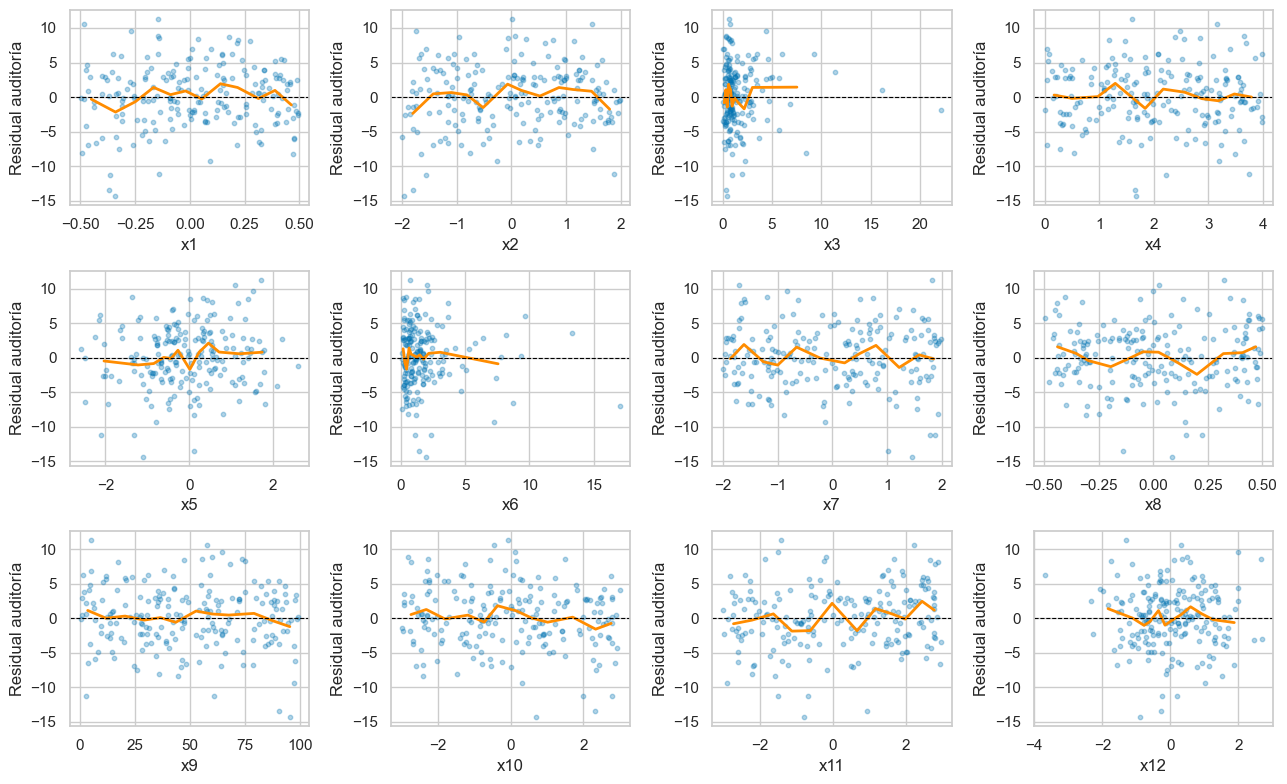

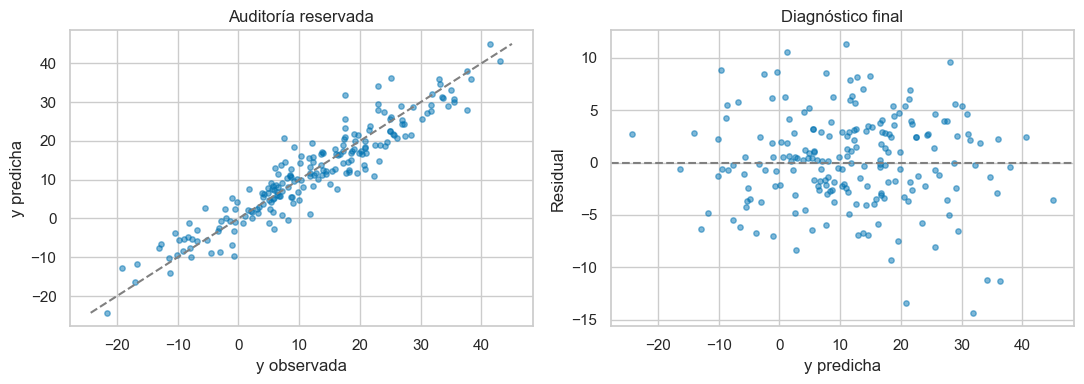

In [14]:
paneles_respuesta(X_val, y_val.to_numpy() - pred_auditoria,
                 "Residual auditoría", "07_residuales_auditoria.png")
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
axes[0].scatter(y_val, pred_auditoria, alpha=0.5, s=15)
limites = [min(y_val.min(), pred_auditoria.min()), max(y_val.max(), pred_auditoria.max())]
axes[0].plot(limites, limites, "--", color="gray")
axes[0].set(xlabel="y observada", ylabel="y predicha", title="Auditoría reservada")
axes[1].scatter(pred_auditoria, y_val.to_numpy() - pred_auditoria, alpha=0.5, s=15)
axes[1].axhline(0, color="gray", linestyle="--")
axes[1].set(xlabel="y predicha", ylabel="Residual", title="Diagnóstico final")
guardar_figura("08_auditoria.png")

## Entrega local

Una vez terminada la auditoría, se vuelven a estimar los coeficientes de la misma
especificación usando las 800 filas. Se generan las 400 predicciones en el orden
original de `test.csv`. El ajuste final ya no tiene una auditoría independiente
dentro de `train`: las métricas anteriores corresponden al modelo ajustado con 600 filas.

In [15]:
test = pd.read_csv(MIS_DATOS / "test.csv")
assert test.shape == (400, 12)
assert list(test.columns) == VARIABLES
assert np.isfinite(test.to_numpy()).all()

matriz_final = construye_final(train)
modelo_final = LinearRegression().fit(matriz_final, train["y"])
predicciones = modelo_final.predict(construye_final(test))
assert predicciones.shape == (400,)
assert np.isfinite(predicciones).all()
assert modelo_final.rank_ == matriz_final.shape[1], "La matriz final tiene colinealidad exacta."

destino = RAIZ / "entregas/tarea-01" / CARPETA / "predicciones.csv"
destino.parent.mkdir(parents=True, exist_ok=True)
# Escribir primero un temporal evita dejar una entrega truncada si falla la escritura.
temporal = destino.with_suffix(".csv.tmp")
pd.DataFrame({"y": predicciones}).to_csv(temporal, index=False)
temporal.replace(destino)
entrega = pd.read_csv(destino)
assert entrega.shape == (400, 1) and list(entrega.columns) == ["y"]
assert np.allclose(entrega["y"], predicciones, rtol=1e-12, atol=1e-12)

coeficientes = pd.DataFrame({
    "termino": ["intercepto", *matriz_final.columns],
    "coeficiente": [modelo_final.intercept_, *modelo_final.coef_],
})
coeficientes.to_csv(RESULTADOS / "coeficientes.csv", index=False)
display(coeficientes)
metricas = {
    "clave": CLAVE_UNICA, "variante": CARPETA,
    "estimador": "sklearn.linear_model.LinearRegression", "columnas": list(matriz_final),
    "filas_desarrollo": 600, "filas_auditoria": 200, "filas_ajuste_final": 800,
    "cv_desarrollo": {"baseline": cv_baseline, "compacto": evaluar_cv(construye_final(X_train)), "lasso": cv_lasso},
    "lasso": {"alpha": float(ajuste_lasso.alpha_), "columnas_candidatas": 454,
              "coeficientes_no_nulos": no_cero_lasso, "MSE_auditoria": mse_lasso_auditoria,
              "iteraciones": int(ajuste_lasso.n_iter_), "dual_gap": float(ajuste_lasso.dual_gap_)},
    "seleccion_en_desarrollo": preferido_cv,
    "versiones": {"python": platform.python_version(), "numpy": np.__version__,
                  "pandas": pd.__version__, "scikit_learn": sklearn.__version__},
    "sha256_datos": {nombre: hashlib.sha256((MIS_DATOS / f"{nombre}.csv").read_bytes()).hexdigest()
                     for nombre in ["train", "test"]},
    "sha256_predicciones": hashlib.sha256(destino.read_bytes()).hexdigest(),
    "auditoria": filas_auditoria, "reduccion_mse_auditoria": mejora,
    "intervalo_bootstrap_mse_95": intervalo.tolist(),
    "predicciones": len(predicciones), "calificacion_oficial_solicitada": False,
}
(RESULTADOS / "metricas.json").write_text(json.dumps(metricas, indent=2, ensure_ascii=False), encoding="utf-8")
print(f"CSV local: {destino.relative_to(RAIZ)}")
print(f"{len(predicciones)} predicciones; rango [{predicciones.min():.2f}, {predicciones.max():.2f}]")
print("No se realizó ningún envío ni solicitud de calificación.")

,termino,coeficiente
0,intercepto,3.112760
1,x11,1.681405
2,x2_cuadrado,3.834337
3,seno_x4,7.246082
4,log_x6,3.207499
5,x7_cubo,2.231611
6,escalon_x9,9.336544
7,interaccion_x1_x11,10.270229


CSV local: entregas\tarea-01\v2e419aae\predicciones.csv
400 predicciones; rango [-26.39, 44.25]
No se realizó ningún envío ni solicitud de calificación.


### Uso y fuentes

- `abrir-tarea-01.ps1` abre JupyterLab sin ejecutar celdas.
- `ejecutar-tarea-01.ps1` ejecuta localmente este notebook y regenera resultados y CSV.
- La revisión local del CSV sólo comprueba dimensiones, orden de construcción y valores finitos.
- La entrega al curso y los comentarios al bot se hacen por separado según `tarea_01_README.md`.

Referencias: [mínimos cuadrados ordinarios](https://scikit-learn.org/stable/modules/linear_model.html#ordinary-least-squares)
y [variables polinomiales](https://scikit-learn.org/stable/modules/preprocessing.html#generating-polynomial-features).

También se consultaron [LassoCV](https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LassoCV.html)
y [prevención de fuga de datos](https://scikit-learn.org/stable/common_pitfalls.html#data-leakage).

**Límites de la entrega local:** la comparación numérica con el MSE meta oficial
requiere obtener ese valor mediante `/validar`. El informe no inventa ese dato ni
una reflexión personal previa del alumno. La publicación y la calificación oficial
son pasos pendientes fuera de este notebook.